
--- Train Metrics ---
Accuracy: 0.7475728155339806
Precision: 0.75625
Recall: 0.75625
F1 Score: 0.75625
Specificity: 0.738255033557047
ROC AUC: 0.8378355704697986
Log Loss: 0.4920914838330513
MCC: 0.494505033557047
Cohen's Kappa: 0.494505033557047
Balanced Accuracy: 0.7472525167785236

--- Test Metrics ---
Accuracy: 0.7744360902255639
Precision: 0.746031746031746
Recall: 0.7704918032786885
F1 Score: 0.7580645161290323
Specificity: 0.7777777777777778
ROC AUC: 0.8679417122040073
Log Loss: 0.45812142029466946
MCC: 0.5471495194554741
Cohen's Kappa: 0.5468998410174881
Balanced Accuracy: 0.7741347905282332


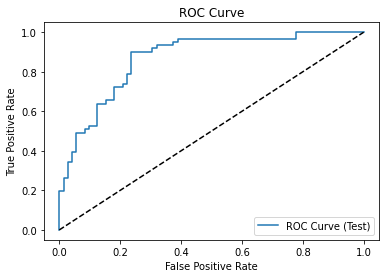

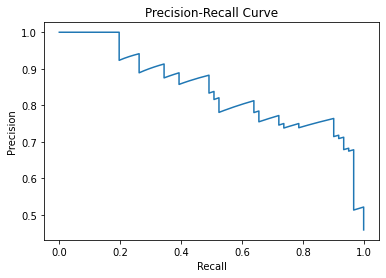

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, log_loss, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
import numpy as np

# Load the diabetes dataset (converted to classification)
# We'll use the original regression target and binarize it
diabetes = load_diabetes()
X = diabetes.data
y = (diabetes.target > 140).astype(int)  # Binary classification: High risk if target > 140

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict classes and probabilities
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Function to calculate specificity
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

# Function to print all metrics
def evaluate_metrics(y_true, y_pred, y_prob, label="Set"):
    print(f"\n--- {label} Metrics ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Specificity:", specificity_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("Log Loss:", log_loss(y_true, y_prob))
    print("MCC:", matthews_corrcoef(y_true, y_pred))
    print("Cohen's Kappa:", cohen_kappa_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))

# Evaluate on train and test
evaluate_metrics(y_train, y_train_pred, y_train_prob, "Train")
evaluate_metrics(y_test, y_test_pred, y_test_prob, "Test")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label="ROC Curve (Test)")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
